# Aula 12


# Inicialização de RNAs

### Eduardo Lobo Lustosa Cabral

## 1. Objetivos


- Apresentrar formas de inicializar parâmetros de uma RNA.

- Apresentar algumas formas de transfromação e normalização de dados.

- Verificar o que acontece se os pesos das ligações são inicializados com constantes.

### Importação das principais de bibliotecas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
tf.__version__

'2.17.0'

## 2. Carregar e processar dados

Nesse exemplo vamos usar o conjunto de dados de doença cardiaca "Heart Disease UCI" (https://www.kaggle.com/ronitf/heart-disease-ucipontos).


### 2.1 Carregar dados de entrada

No código da célula abaixo é importado o conjunto de dados.

In [ ]:
df_orig = pd.read_csv('heart.csv')
df_orig

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


### 2.2 Calcular estatísticas báscas dos dados

In [ ]:
df_orig.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2.3 Transformação dos dados

É necessário transformar colunas com valores categóricos para vetores one_hot.

É conveniente fazer essa transformação antes da divisão dos dados em conjuntos de treinamento e validação/teste.

As colunas com variáveis categóricas são as seguintes:

- cp
- restecg
- slope
- ca
- thal

Primeiramente vamos verifcar os valores únicos dessas colunas.

In [ ]:
# Valores únicos das colunas
print('Valore únicos de cp:', df_orig.cp.unique())
print('Valore únicos de restecg:',df_orig.restecg.unique())
print('Valore únicos de slope:', df_orig.slope.unique())
print('Valore únicos de ca:', df_orig.ca.unique())
print('Valore únicos de thal:',df_orig.thal.unique())

Valore únicos de cp: [3 2 1 0]
Valore únicos de restecg: [0 1 2]
Valore únicos de slope: [0 2 1]
Valore únicos de ca: [0 2 1 3 4]
Valore únicos de thal: [1 2 3 0]


In [ ]:
# Salva dataframe original
df = df_orig.copy()

# Codificação one-hot da coluna cp
df_cp_hot = pd.get_dummies(df["cp"], dtype=int,prefix='cp') #add prefix to new columns

# Codificação one-hot da coluna restecg
df_rest_hot = pd.get_dummies(df["restecg"], dtype=int,prefix='restecg') #add prefix to new columns

# Codificação one-hot da coluna slope
df_slope_hot = pd.get_dummies(df["slope"], dtype=int,prefix='slope') #add prefix to new columns

# Codificação one-hot da coluna cae
df_ca_hot = pd.get_dummies(df["ca"], dtype=int,prefix='ca') #add prefix to new columns

# Codificação one-hot da coluna thal
df_thal_hot = pd.get_dummies(df["thal"], dtype=int,prefix='thal') #add prefix to new columns

# União do resultado das codificações one-hot com dataframe original
#df = pd.concat([df, df_dummies], axis=1)
df = df.join(df_cp_hot)
df = df.join(df_rest_hot)
df = df.join(df_slope_hot)
df = df.join(df_ca_hot)
df = df.join(df_thal_hot)

# Remoção da coluna original "Pclass"
df = df.drop(columns=['cp'])
df = df.drop(columns=['restecg'])
df = df.drop(columns=['slope'])
df = df.drop(columns=['ca'])
df = df.drop(columns=['thal'])

df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,target,cp_0,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,1,0,...,0,1,0,0,0,0,0,1,0,0
1,37,1,130,250,0,187,0,3.5,1,0,...,0,1,0,0,0,0,0,0,1,0
2,41,0,130,204,0,172,0,1.4,1,0,...,1,1,0,0,0,0,0,0,1,0
3,56,1,120,236,0,178,0,0.8,1,0,...,1,1,0,0,0,0,0,0,1,0
4,57,0,120,354,0,163,1,0.6,1,1,...,1,1,0,0,0,0,0,0,1,0


### 2.4 Divisão do conjunto de dados

Vamos dividir o conjunto de dados em conjuntos de treinamento e teste.

In [ ]:
# Usaremos a função split da biblioteca sklearn para divir os dados
train_df, test_df = train_test_split(df, test_size=0.2)

# Separa as saídas dos dados de entrada e as transforma em tensores Numpy
Y_train = np.array(train_df.pop('target'))
Y_test = np.array(test_df.pop('target'))

### 2.5 Normalização dos dados

Vamos normalizar as colunas com valores reais, ou seja, as colunas `age`, `trestbps`, `thalach`, `chol` e `oldpeak`.

A normalização será realizada para as colunas tenham média 0 e desvio padraõa igual a 1.

Nessa normalização devemos usar os valores médios e desvios padrões somente dos dados de treinamento.

In [ ]:
train_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
136,60,0,120,178,1,96,0,0.0,0,0,...,1,1,0,0,0,0,0,0,1,0
142,42,0,120,209,0,173,0,0.0,0,0,...,0,1,0,0,0,0,0,0,1,0
65,35,0,138,183,0,182,0,1.4,1,0,...,1,1,0,0,0,0,0,0,1,0
178,43,1,120,177,0,120,1,2.5,1,0,...,0,1,0,0,0,0,0,0,0,1
200,44,1,110,197,0,177,0,0.0,1,0,...,1,0,1,0,0,0,0,0,1,0


In [ ]:
# Calculo das médias e desvios padrões
mean_age = train_df['age'].mean()
std_age = train_df['age'].std()
mean_tres = train_df['trestbps'].mean()
std_tres = train_df['trestbps'].std()
mean_thal = train_df['thalach'].mean()
std_thal = train_df['thalach'].std()
mean_col = train_df['chol'].mean()
std_col = train_df['chol'].std()
mean_col = train_df['chol'].mean()
std_col = train_df['chol'].std()
mean_oldpeak = train_df['oldpeak'].mean()
std_oldpeak = train_df['oldpeak'].std()

In [ ]:
# Normalização dos dados de treinamento
train_df['age'] = (train_df['age'] - mean_age)/std_age
train_df['trestbps'] = (train_df['trestbps'] - mean_tres)/std_tres
train_df['thalach'] = (train_df['thalach'] - mean_thal)/std_thal
train_df['chol'] = (train_df['chol'] - mean_col)/std_col
train_df['oldpeak'] = (train_df['oldpeak'] - mean_oldpeak)/std_oldpeak
train_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
136,0.626848,0,-0.638065,-1.289788,1,-2.315951,0,-0.864976,0,0,...,1,1,0,0,0,0,0,0,1,0
142,-1.356121,0,-0.638065,-0.697586,0,1.014457,0,-0.864976,0,0,...,0,1,0,0,0,0,0,0,1,0
65,-2.127276,0,0.394789,-1.194271,0,1.403726,0,0.311947,1,0,...,1,1,0,0,0,0,0,0,1,0
178,-1.245956,1,-0.638065,-1.308891,0,-1.277902,1,1.236673,1,0,...,0,1,0,0,0,0,0,0,0,1
200,-1.135792,1,-1.211872,-0.926825,0,1.187466,0,-0.864976,1,0,...,1,0,1,0,0,0,0,0,1,0


In [ ]:
# Normalização dos dados de testeo
test_df['age'] = (test_df['age'] - mean_age)/std_age
test_df['trestbps'] = (test_df['trestbps'] - mean_tres)/std_tres
test_df['thalach'] = (test_df['thalach'] - mean_thal)/std_thal
test_df['chol'] = (test_df['chol'] - mean_col)/std_col
test_df['oldpeak'] = (test_df['oldpeak'] - mean_oldpeak)/std_oldpeak
test_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_0,cp_1,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
40,-0.364637,0,0.509551,1.193640,0,-0.326356,0,0.396013,0,0,...,1,0,1,0,0,0,0,0,1,0
108,-0.474802,0,-0.638065,-0.028971,0,0.538685,0,0.059749,0,1,...,1,1,0,0,0,0,0,0,1,0
160,0.186188,1,-0.638065,-0.105384,0,0.841449,0,-0.864976,0,1,...,0,1,0,0,0,0,0,0,1,0
247,1.287837,1,1.657166,0.009236,0,-1.277902,1,-0.864976,0,1,...,0,0,0,0,1,0,0,1,0,0
52,0.847178,1,-0.064257,-0.277313,0,-0.153348,0,0.648211,0,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
# Transforma os dados de entrada em tensores Numpy
X_train = np.array(train_df)
X_test = np.array(test_df)

In [ ]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,242.0,-2.936127e-17,1.000000,-2.788266,-0.805297,0.076023,0.709471,2.499652
sex,242.0,6.776860e-01,0.468331,0.000000,0.000000,1.000000,1.000000,1.000000
trestbps,242.0,7.762386e-16,1.000000,-2.129964,-0.638065,-0.064257,0.509551,3.952396
chol,242.0,-4.404191e-17,1.000000,-2.283159,-0.659379,-0.114935,0.525025,6.084082
fbs,242.0,1.528926e-01,0.360630,0.000000,0.000000,0.000000,0.000000,1.000000
thalach,242.0,5.505238e-16,1.000000,-3.397252,-0.575056,0.127790,0.711693,2.268767
exang,242.0,3.388430e-01,0.474297,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,242.0,-2.936127e-17,1.000000,-0.864976,-0.864976,-0.360580,0.480079,4.347113
cp_0,242.0,4.752066e-01,0.500420,0.000000,0.000000,0.000000,1.000000,1.000000
cp_1,242.0,1.694215e-01,0.375901,0.000000,0.000000,0.000000,0.000000,1.000000


## 3. Configuração da rede

A inicialização dos parâmetros de um RNA é realizada por camadas no momento em que ela é incluída na RNA.

Vamos verificar o que ocorre no treinamento de uma rede quando inicilizarmos os parâmetros de diferentes formas.

Os inicializadores existentes do Keras podem ser vistos em https://www.tensorflow.org/api_docs/python/tf/keras/initializers.

In [ ]:
# Importar do Keras classes de modelos e camadas
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import initializers

# Define dimensão da entrada
xdim = X_train.shape[1]

# Definiação da inicialização dos pessos das ligações
initializer = tf.keras.initializers.Constant(1.0)
#initializer = tf.keras.initializers.RandomUniform(minval=-0.01, maxval=0.01, seed=None)
#initializer = tf.keras.initializers.GlorotNormal()

# Configuração da rede com pesos e bias inicilizados com zeros
rna = Sequential()
rna.add(Dense(units=64, activation='relu', kernel_initializer=initializer, bias_initializer='zeros', input_dim=xdim))
rna.add(Dense(units=32, activation='relu', kernel_initializer=initializer, bias_initializer='zeros'))
rna.add(Dense(units=1, activation='sigmoid', kernel_initializer=initializer, bias_initializer='zeros'))

rna.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compilação e treinamento da rede

In [ ]:
EPOCHS = 50

# Compilação da rede
rna.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])

# Treinamento da RN
history = rna.fit(X_train, Y_train, epochs=EPOCHS, validation_data=(X_test, Y_test), verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.5859 - loss: 5837.8608 - val_accuracy: 0.5082 - val_loss: 6965.1060
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5356 - loss: 6497.1465 - val_accuracy: 0.5082 - val_loss: 6790.2632
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5121 - loss: 6594.8413 - val_accuracy: 0.5082 - val_loss: 6621.0811
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5441 - loss: 6267.3911 - val_accuracy: 0.5082 - val_loss: 6456.0879
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5194 - loss: 6351.7524 - val_accuracy: 0.5082 - val_loss: 6295.0063
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5682 - loss: 5674.7051 - val_accuracy: 0.5082 - val_loss: 6139.6895
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5755 - loss: 5255.6738 - val_accuracy: 0.5082 - val_loss: 5987.4487
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5456 - loss: 5577.0586 - v

## 5. Resultados do treinamento

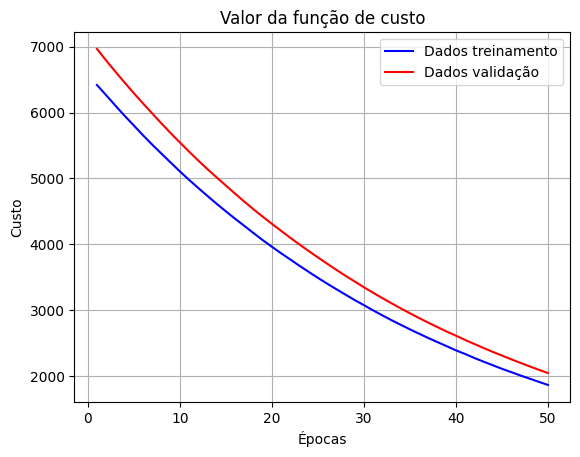

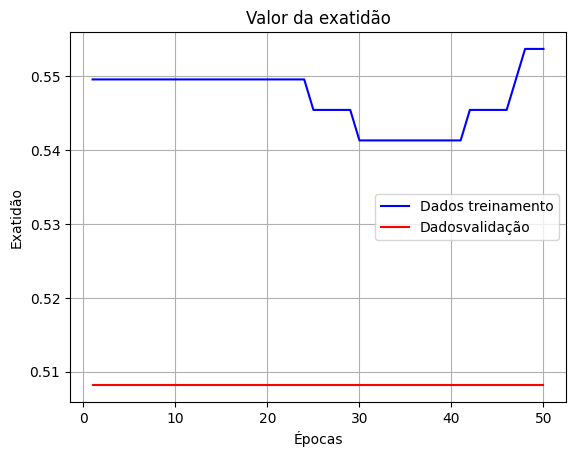

In [ ]:
# Recupera hostorico do treinamento
history_dict = history.history

# Salva custo e exatidão em vetores
custo = history_dict['loss']
exatidao = history_dict['accuracy']
val_custo = history_dict['val_loss']
val_exatidao = history_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico do custo em funçaõ das épocas
plt.plot(epocas, custo, 'b', label='Dados treinamento')
plt.plot(epocas, val_custo, 'r', label='Dados validação')
plt.title('Valor da função de custo')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend()
plt.grid()
plt.show()

# Gráfico da exatidão em função das épocas
plt.plot(epocas, exatidao, 'b', label='Dados treinamento')
plt.plot(epocas, val_exatidao, 'r', label='Dadosvalidação')
plt.title('Valor da exatidão')
plt.xlabel('Épocas')
plt.ylabel('Exatidão')
plt.legend()
plt.grid()
plt.show()

### Avaliação dos resultados

Vamos avaliar a RN com o conjunto de dados de teste e obter os resultados para as métricas que foram utilizadas.

In [ ]:
# Usando método evaluate calcule o custo e a exatidão para os dados de treinamento e depois apresente os resultados
custo_e_metricas_train = rna.evaluate(X_train,Y_train)
print(custo_e_metricas_train)

# Usando método evaluate calcule o custo e a exatidão para os dados de teste e depois apresente os resultados
custo_e_metricas_test = rna.evaluate(X_test, Y_test)
print(custo_e_metricas_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5570 - loss: 1814.7281
[1843.9649658203125, 0.5537189841270447]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5055 - loss: 2069.2686 
[2050.144775390625, 0.5081967115402222]
